In [2]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "data" / "raw" / "WESAD" / "WESAD"
print(DATA_DIR.resolve())
print(DATA_DIR.exists())

subjects = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
print(subjects)

C:\Users\maheshbh\wearable-affect\data\raw\WESAD\WESAD
True
['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [17]:
with open(DATA_DIR / "S3" / "S3.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))
print(data.keys())
print(data["signal"].keys())
print(data["signal"]["wrist"].keys())
print(data["signal"]["wrist"]["ACC"].shape)

<class 'dict'>
dict_keys(['signal', 'label', 'subject'])
dict_keys(['chest', 'wrist'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
(207776, 3)


In [18]:
DATA_DIR

WindowsPath('../data/raw/WESAD/WESAD')

In [19]:
sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])

['S10',
 'S11',
 'S13',
 'S14',
 'S15',
 'S16',
 'S17',
 'S2',
 'S3',
 'S4',
 'S5',
 'S6',
 'S7',
 'S8',
 'S9']

In [20]:
FS = {"ACC": 32, "BVP": 64, "EDA": 4, "TEMP": 4, "label": 700}

for name, signal in data["signal"]["wrist"].items():
    n = signal.shape[0]
    print(f"{name:5s} shape={str(signal.shape):14s} duration={n / FS[name] / 60:6.1f} min")

labels = data["label"]
print(f"label shape={labels.shape} duration={len(labels) / FS['label'] / 60:6.1f} min")

ACC   shape=(207776, 3)    duration= 108.2 min
BVP   shape=(415552, 1)    duration= 108.2 min
EDA   shape=(25972, 1)     duration= 108.2 min
TEMP  shape=(25972, 1)     duration= 108.2 min
label shape=(4545100,) duration= 108.2 min


In [21]:
LABEL_NAMES = {0: "not defined / transient", 1: "baseline", 2: "stress",
               3: "amusement", 4: "meditation", 5: "ignore", 6: "ignore", 7: "ignore"}

values, counts = np.unique(labels, return_counts=True)
for v, c in zip(values, counts):
    print(f"{v}: {LABEL_NAMES[v]:25s} {c / FS['label'] / 60:6.1f} min")

0: not defined / transient     55.8 min
1: baseline                    19.0 min
2: stress                      10.7 min
3: amusement                    6.2 min
4: meditation                  13.0 min
5: ignore                       1.2 min
6: ignore                       1.1 min
7: ignore                       1.1 min


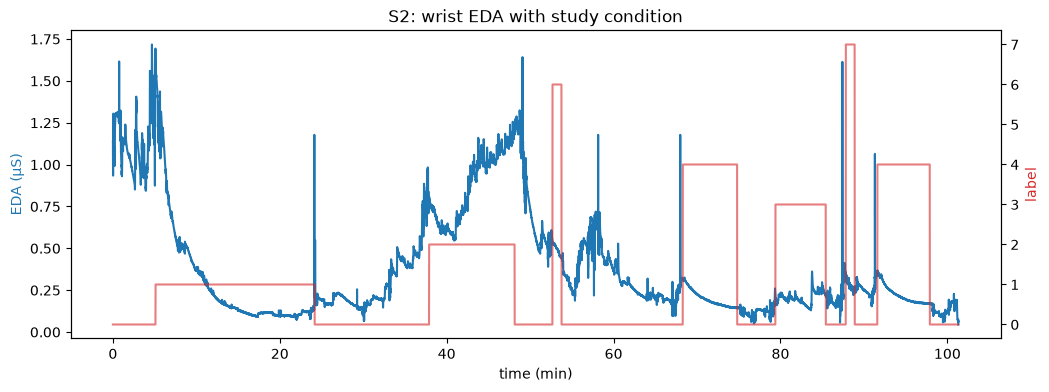

In [16]:
eda = data["signal"]["wrist"]["EDA"][:, 0]
t_eda = np.arange(len(eda)) / FS["EDA"] / 60
t_label = np.arange(len(labels)) / FS["label"] / 60

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(t_eda, eda, color="tab:blue")
ax1.set_xlabel("time (min)")
ax1.set_ylabel("EDA (µS)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(t_label[::700], labels[::700], color="tab:red", alpha=0.6)
ax2.set_ylabel("label", color="tab:red")
plt.title("S2: wrist EDA with study condition")
plt.show()

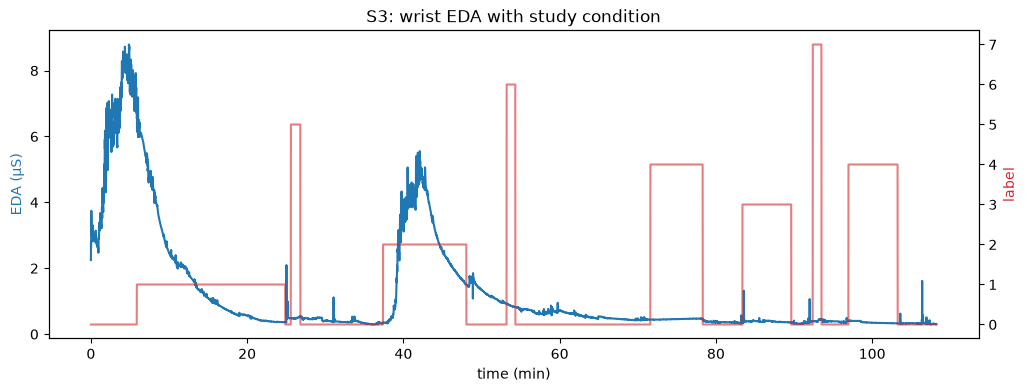

In [22]:
eda = data["signal"]["wrist"]["EDA"][:, 0]
t_eda = np.arange(len(eda)) / FS["EDA"] / 60
t_label = np.arange(len(labels)) / FS["label"] / 60

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(t_eda, eda, color="tab:blue")
ax1.set_xlabel("time (min)")
ax1.set_ylabel("EDA (µS)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(t_label[::700], labels[::700], color="tab:red", alpha=0.6)
ax2.set_ylabel("label", color="tab:red")
plt.title("S3: wrist EDA with study condition")
plt.show()

In [4]:
# labels
quest_path = DATA_DIR / "S14" / "S14_quest.csv"
print(quest_path.read_text())

# Subj;S14;;;;;;;;;;;;;;;;;;;;;;;;;
# ORDER;Base;TSST;Medi 2;Fun;Medi 1;bRead;sRead;fRead;;;;;;;;;;;;;;;;;;
# START;2;33.18;62.22;73.24;84.29;22.14;49.47;80.36;;;;;;;;;;;;;;;;;;
# END;22;44.53;69.19;79.56;91.26;23.37;51.02;81.5;;;;;;;;;;;;;;;;;;
;;;;;;;;;;;;;;;;;;;;;;;;;;
# PANAS;1;1;3;1;1;3;1;1;1;1;1;1;2;1;3;1;3;3;1;1;1;1;3;1;;
# PANAS;4;1;3;1;1;3;1;3;1;4;3;1;2;1;5;4;4;5;1;1;4;2;3;1;2;1
# PANAS;1;1;3;1;1;3;1;1;1;3;3;1;2;1;3;2;3;4;1;1;2;1;3;1;;
# PANAS;1;1;3;2;1;3;1;1;1;2;3;1;2;1;3;1;1;4;1;1;1;1;3;1;;
# PANAS;1;1;3;1;1;3;1;1;1;1;3;1;3;1;4;1;1;4;1;1;1;1;3;1;;
;;;;;;;;;;;;;;;;;;;;;;;;;;
# STAI;1;1;2;3;1;2;;;;;;;;;;;;;;;;;;;;
# STAI;1;3;2;1;1;1;;;;;;;;;;;;;;;;;;;;
# STAI;1;2;2;4;1;2;;;;;;;;;;;;;;;;;;;;
# STAI;1;1;2;3;1;3;;;;;;;;;;;;;;;;;;;;
# STAI;1;1;1;3;1;1;;;;;;;;;;;;;;;;;;;;
;;;;;;;;;;;;;;;;;;;;;;;;;;
# DIM;5;2;;;;;;;;;;;;;;;;;;;;;;;;
# DIM;3;7;;;;;;;;;;;;;;;;;;;;;;;;
# DIM;4;3;;;;;;;;;;;;;;;;;;;;;;;;
# DIM;7;2;;;;;;;;;;;;;;;;;;;;;;;;
# DIM;7;2;;;;;;;;;;;;;;;;;;;;;;;;
;;;;;;;;;;;;;;;;

In [5]:
import pandas as pd
from wearable_affect.data import DEFAULT_DATA_DIR, list_subjects, load_self_reports

subjects = list_subjects(DEFAULT_DATA_DIR)
reports = pd.concat([load_self_reports(DEFAULT_DATA_DIR, s) for s in subjects])
wide = reports.pivot(index="subject_id", columns="condition", values=["valence", "arousal"])

check = pd.DataFrame({
    "arousal_base": wide["arousal"]["Base"],
    "arousal_tsst": wide["arousal"]["TSST"],
    "valence_base": wide["valence"]["Base"],
    "valence_tsst": wide["valence"]["TSST"],
}).reindex(subjects)
check["arousal_change"] = check["arousal_tsst"] - check["arousal_base"]
check["valence_change"] = check["valence_tsst"] - check["valence_base"]
check

,arousal_base,arousal_tsst,valence_base,valence_tsst,arousal_change,valence_change
subject_id,,,,,,
S10,2.0,8.0,6.0,3.0,6.0,-3.0
S11,2.0,6.0,6.0,4.0,4.0,-2.0
S13,3.0,9.0,5.0,4.0,6.0,-1.0
S14,2.0,7.0,5.0,3.0,5.0,-2.0
S15,5.0,8.0,6.0,4.0,3.0,-2.0
S16,2.0,8.0,7.0,3.0,6.0,-4.0
S17,2.0,9.0,7.0,1.0,7.0,-6.0
S2,2.0,4.0,7.0,5.0,2.0,-2.0
S3,4.0,7.0,7.0,7.0,3.0,0.0


In [6]:
from scipy.stats import spearmanr

baseline = per_subject("all_handcrafted-lightgbm")
scl = features.groupby(["subject_id", "target"])["scl_mean"].mean().unstack()

check["auroc"] = baseline["auroc"]
check["scl_change"] = scl[1] - scl[0]

print(spearmanr(check["arousal_change"], check["auroc"]))
print(spearmanr(check["arousal_change"], check["scl_change"]))

NameError: name 'per_subject' is not defined